# Chess Space Control Prediction & Move Reranking (ML/DL Hybrid)

This notebook extends our study on *Space Control in Chess across ELO ranges*  
by integrating Machine Learning and Deep Learning techniques.

### Goals:
- Predict future spatial control using ML.
- Predict game outcomes based on position features.
- Implement a lightweight reranker that mimics Leela Chess Zero's intuition.


## Project Continuation Update (This Semester xAI)

New contributions compared to previous semester:
1. CNN-based board evaluation trained on Stockfish centipawn scores
2. Engine-supervised learning using real Stockfish evaluations
3. Explainable move reranking system
4. Quantitative comparison with Stockfish (correlation, CP error)


In [1]:
import pandas as pd
import numpy as np
import chess
import chess.pgn
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)



In [2]:
df = pd.read_csv('games.csv')
print("Total games:", len(df))


Total games: 20058


In [3]:
# feature extraction functions

def board_after_fullmove(moves_san, fullmove_number):
    board = chess.Board()
    if not isinstance(moves_san, str): return board
    tokens = moves_san.strip().split()
    ply_count = fullmove_number * 2
    for m in tokens[:ply_count]:
        try:
            board.push_san(m)
        except:
            break
    return board

def space_control_diff(board):
    white_ctrl, black_ctrl = 0, 0
    for sq in chess.SQUARES:
        if board.attackers(chess.WHITE, sq) and not board.attackers(chess.BLACK, sq):
            white_ctrl += 1
        elif board.attackers(chess.BLACK, sq) and not board.attackers(chess.WHITE, sq):
            black_ctrl += 1
    return white_ctrl - black_ctrl, white_ctrl, black_ctrl

def material_balance(board):
    values = {chess.PAWN:1, chess.KNIGHT:3, chess.BISHOP:3, chess.ROOK:5, chess.QUEEN:9}
    return sum(values[p]*(
        len(board.pieces(p, chess.WHITE)) - len(board.pieces(p, chess.BLACK))
    ) for p in values)


In [4]:
# extracting game features
rows = []
for _, row in df.iterrows():
    moves = row['moves']
    b10 = board_after_fullmove(moves, 10)
    b15=board_after_fullmove(moves,15)
    b20 = board_after_fullmove(moves, 20)
    diff10, w10, b10c = space_control_diff(b10)
    diff20, w20, b20c = space_control_diff(b20)
    '''
    rows.append({
        'white_rating': row['white_rating'],
        'black_rating': row['black_rating'],
        'elo_diff': row['white_rating'] - row['black_rating'],
        'space10_diff': diff10,
        'space20_diff': diff20,
        'mat10': material_balance(b10),
        'winner': row['winner']
    })'''
    rows.append({
        'white_rating': row['white_rating'],
        'black_rating': row['black_rating'],
        'elo_diff': row['white_rating'] - row['black_rating'],
        'space10_diff': diff10,
        'space20_diff': diff20,
        'mat10': material_balance(b10),
        'mat15': material_balance(b15),
        'winner': row['winner'],
        'mat20':material_balance(b20),
        'elo_diff**2': (row['white_rating'] - row['black_rating'])**2,
        '(white_rating + black_rating)/2': (row['white_rating'] + row['black_rating'])/2,
        'abs_elo_diff': abs(row['white_rating']-row['black_rating'])
    })
feat = pd.DataFrame(rows).dropna()
feat.head()


,white_rating,black_rating,elo_diff,space10_diff,space20_diff,mat10,mat15,winner,mat20,elo_diff**2,(white_rating + black_rating)/2,abs_elo_diff
0,1500,1191,309,5,5,1,1,white,1,95481,1345.5,309
1,1322,1261,61,-7,-7,-9,-9,black,-9,3721,1291.5,61
2,1496,1500,-4,5,30,4,17,white,21,16,1498.0,4
3,1439,1454,-15,5,17,-1,0,white,12,225,1446.5,15
4,1523,1469,54,-1,1,0,0,white,5,2916,1496.0,54


In [5]:
# RandomForest Regressor
X = feat[[
    'white_rating',
    'black_rating', 
    'elo_diff',
    'elo_diff**2',
    'abs_elo_diff',                        
    '(white_rating + black_rating)/2',
    'space10_diff',                        # duplicate removed
    'mat10',
    'mat15',
    'mat20'
]]
y = feat['space20_diff']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,       # up from 300
    max_depth=12,           # up from 10
    min_samples_split=4,
    min_samples_leaf=2,     # prevents overfitting on noisy positions
    n_jobs=-1,              # uses all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print(f"R² Score: {r2_score(y_test, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.4f}")

R² Score: 0.5146
RMSE: 5.0347


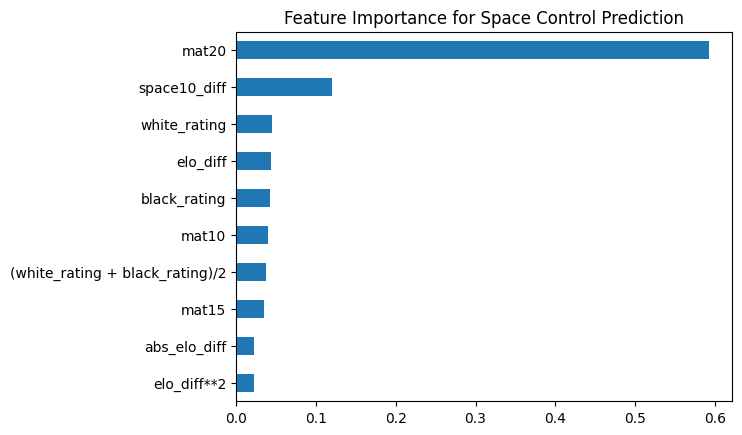

In [6]:
imp = pd.Series(rf.feature_importances_, index=X.columns)
imp.sort_values().plot(kind='barh', title="Feature Importance for Space Control Prediction")
plt.show()


In [7]:
feat['result'] = feat['winner'].map({'white':1, 'black':2}).fillna(0)

# fixed feature order - no duplicate, added abs_elo_diff, matches Cell 11
Xm = feat[[
    'white_rating',
    'black_rating',
    'elo_diff',
    'elo_diff**2',
    'abs_elo_diff',       # ← added
    'space10_diff',       # ← duplicate removed
    'mat10',
    'mat15',
    'mat20'
]]
ym = feat['result']

scaler = StandardScaler()
Xm_s = scaler.fit_transform(Xm)
Xtr, Xte, ytr, yte = train_test_split(Xm_s, ym, test_size=0.2, random_state=42)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # ← wider, was (128,64,32)
    activation='relu',
    solver='adam',
    alpha=1e-3,                          # ← stronger regularization, was 1e-4
    learning_rate_init=1e-3,             # ← fixed, was 7e-2 (too high, caused instability)
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,             # ← added explicit validation split
    random_state=42
)

mlp.fit(Xtr, ytr)
predm = mlp.predict(Xte)

print("Accuracy:", accuracy_score(yte, predm))
print(classification_report(yte, predm))

Accuracy: 0.7228315054835494
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       192
         1.0       0.74      0.77      0.75      2004
         2.0       0.71      0.74      0.73      1816

    accuracy                           0.72      4012
   macro avg       0.48      0.51      0.49      4012
weighted avg       0.69      0.72      0.71      4012



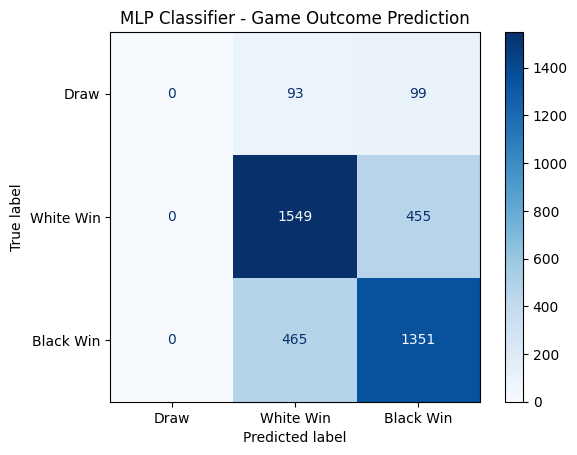

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(yte, predm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Draw','White Win','Black Win'])
disp.plot(cmap='Blues', values_format='d')
plt.title("MLP Classifier - Game Outcome Prediction")
plt.show()


### Local Explanation: Move Reranking

The model evaluates multiple legal moves and explains its preference by:
- Predicted centipawn change
- Win probability shift
- Comparison with Stockfish


🔹 Game ID: 18691
White Rating: 1500 | Black Rating: 1796
Winner: black



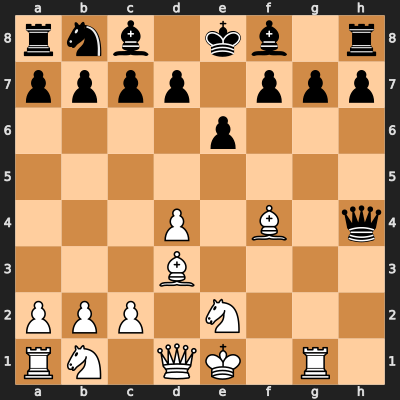

FEN: rnb1kb1r/pppp1ppp/4p3/8/3P1B1q/3B4/PPP1N3/RN1QK1R1 w kq - 2 11

♟️  Top Reranked Moves (Leela-style intuition):

Move    Score     White Win%  Black Win%  
------------------------------------------
g1g3    -0.882    0.267       0.697       
e1d2    -1.373    0.235       0.73        
e1f1    -1.373    0.235       0.73        
e2g3    -1.373    0.235       0.73        
f4g3    -2.272    0.205       0.762       

💡 Stockfish best move: e1d2 (192 cp)
🤖 Model top move: g1g3 (126 cp)
🟡 Model differs slightly (66 cp difference)


In [9]:
import chess.svg
from IPython.display import display, SVG
import pandas as pd

sample = df.sample(1).iloc[0]
board = board_after_fullmove(sample['moves'], 10)
print(f"🔹 Game ID: {sample.name}")
print(f"White Rating: {sample['white_rating']} | Black Rating: {sample['black_rating']}")
print(f"Winner: {sample['winner']}\n")

display(SVG(chess.svg.board(board=board, size=400)))
print("FEN:", board.fen())

moves = list(board.legal_moves)[:10]
ranked = []

for mv in moves:
    b_copy = board.copy()
    b_copy.push(mv)

    wr = sample['white_rating']
    br = sample['black_rating']
    elo_diff = wr - br
    space_now = space_control_diff(b_copy)[0]
    mat10 = material_balance(b_copy)
    mat15 = mat10
    mat20 = mat10
    mean_elo = (wr + br) / 2
    abs_elo = abs(elo_diff)               # ← ADD: new feature

    # fixed feature order - no duplicate, matches RF training
    rf_input = pd.DataFrame([[
        wr, br, elo_diff, elo_diff**2,
        abs_elo, mean_elo,
        space_now, mat10, mat15, mat20
    ]], columns=[
        'white_rating', 'black_rating', 'elo_diff', 'elo_diff**2',
        'abs_elo_diff', '(white_rating + black_rating)/2',
        'space10_diff', 'mat10', 'mat15', 'mat20'
    ])

    space_pred = rf.predict(rf_input)[0]

    # MLP feature order - no duplicate, matches MLP training
    Xmeta = pd.DataFrame([[
        wr, br, elo_diff, elo_diff**2,
        abs_elo, space_now, mat10, mat15, mat20
    ]], columns=[
        'white_rating', 'black_rating', 'elo_diff', 'elo_diff**2',
        'abs_elo_diff', 'space10_diff', 'mat10', 'mat15', 'mat20'
    ])
    Xmeta_scaled = scaler.transform(Xmeta)
    probs = mlp.predict_proba(Xmeta_scaled)[0]

    score = space_pred * 0.5 + (probs[1] - probs[2]) * 3.0
    ranked.append((mv.uci(), round(score,3), round(probs[1],3), round(probs[2],3)))

ranked = sorted(ranked, key=lambda x: x[1], reverse=True)

print("\n♟️  Top Reranked Moves (Leela-style intuition):\n")
print(f"{'Move':<8}{'Score':<10}{'White Win%':<12}{'Black Win%':<12}")
print("-"*42)
for mv, sc, wp, bp in ranked[:8]:
    print(f"{mv:<8}{sc:<10}{wp:<12}{bp:<12}")

# Compare with Stockfish
try:
    from stockfish import Stockfish
    engine = Stockfish(
        path=r"C:\Users\vsriv\Downloads\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe",
        depth=14
    )
    engine.set_fen_position(board.fen())
    best_move = engine.get_best_move()
    best_eval = engine.get_evaluation()['value']

    model_top = ranked[0][0]
    b_test = board.copy()
    b_test.push_uci(model_top)
    engine.set_fen_position(b_test.fen())
    model_eval = engine.get_evaluation()['value']

    print(f"\n💡 Stockfish best move: {best_move} ({best_eval} cp)")
    print(f"🤖 Model top move: {model_top} ({model_eval} cp)")

    diff = abs(model_eval - best_eval)
    if model_top == best_move:
        print("✅ Model agrees with Stockfish!")
    elif diff < 50:
        print(f"🟢 Model found a comparable move! ({diff} cp difference)")
    elif diff < 150:
        print(f"🟡 Model differs slightly ({diff} cp difference)")
    else:
        print(f"🔴 Model move significantly worse ({diff} cp difference)")
except Exception:
    print("\n⚠️ Stockfish not found — skipping engine comparison.")

## CNN Demo Predictions

In [10]:
import numpy as np
import pandas as pd
import chess
from stockfish import Stockfish
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [11]:
from tqdm import tqdm
import numpy as np
import chess
from stockfish import Stockfish

engine = Stockfish(
    path=r"C:\Users\vsriv\Downloads\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe",
    depth=8
)

def board_to_tensor(board):
    planes = np.zeros((8, 8, 12), dtype=np.float32)
    mapping = {'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
               'p':6,'n':7,'b':8,'r':9,'q':10,'k':11}
    for sq, piece in board.piece_map().items():
        row = 7 - (sq // 8)
        col = sq % 8
        planes[row, col, mapping[piece.symbol()]] = 1
    return planes

# --- Collect data ---
X, y = [], []
sample_boards = []   # ← ADD THIS: save raw board objects for hybrid weight learning

sampled = df.sample(10000, random_state=42)

for _, row in tqdm(sampled.iterrows(), total=len(sampled)):
    try:
        b = board_after_fullmove(row['moves'], 10)
        if b.is_valid():
            engine.set_fen_position(b.fen())
            val = engine.get_evaluation()['value']
            if isinstance(val, (int, float)):
                val = int(np.clip(val, -1500, 1500))   # ← ADD THIS: clip outlier mate scores
                X.append(board_to_tensor(b))
                y.append(val)
                sample_boards.append(b.copy())          # ← ADD THIS: save the board
    except Exception:
        continue

X = np.array(X)
y = np.array(y)
sf_evaluations = np.array(y)   # ← ADD THIS: alias for hybrid weight cell

print(f"Collected: {len(X)} valid positions")
print(f"CP range: min={y.min()}, max={y.max()}, mean={y.mean():.1f}")

100%|██████████| 10000/10000 [00:57<00:00, 174.97it/s]

Collected: 10000 valid positions
CP range: min=-1140, max=1500, mean=60.7


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split

# --- Define CNN model ---
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(8,8,12), padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='huber'
)

# --- Callbacks (defined BEFORE fit) ---
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train ---
hist = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# --- Evaluate ---
mse = model.evaluate(X_test, y_test, verbose=1)
print(f"Test MSE: {mse:.4f}")

# --- Quick sample prediction ---
import random
idx = random.randint(0, len(X_test)-1)
pred = model.predict(X_test[idx:idx+1], verbose=0)[0][0]
print(f"Model predicted eval: {pred:.2f} | Stockfish actual: {y_test[idx]:.2f}")

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 188.5579 - val_loss: 191.9540 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 169.9472 - val_loss: 189.4482 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 155.9918 - val_loss: 156.4434 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 142.9230 - val_loss: 186.6225 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 130.9298 - val_loss: 143.4875 - learning_rate: 0.0010
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 120.7121 - val_loss: 143.0119 - learning_rate: 0.0010
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 112.4024 - val_loss: 138.1388 - learning_rate: 0.0010
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 102.9805 - val_loss: 164.1668 - learning_rate: 0.0010
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 100.4272 -

In [13]:
from scipy.stats import pearsonr

preds = model.predict(X_test).flatten()
corr, _ = pearsonr(preds, y_test)
print("Pearson Correlation with Stockfish:", round(corr, 3))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Pearson Correlation with Stockfish: 0.708


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


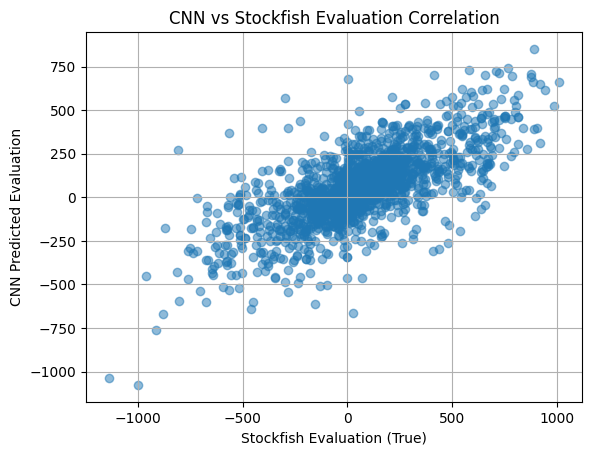

🔗 Correlation: 0.708


In [14]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test).flatten()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Stockfish Evaluation (True)")
plt.ylabel("CNN Predicted Evaluation")
plt.title("CNN vs Stockfish Evaluation Correlation")
plt.grid(True)
corr = np.corrcoef(y_test, y_pred)[0,1]
plt.show()
print(f"🔗 Correlation: {corr:.3f}")


In [15]:
import numpy as np
import chess

In [16]:
'''
MOVED TO BOARD TENSOR CONVERSION
def fen_to_tensor(board):
    piece_map = board.piece_map()
    tensor = np.zeros((8,8,12))

    piece_index = {
        'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
        'p':6,'n':7,'b':8,'r':9,'q':10,'k':11
    }

    for square, piece in piece_map.items():
        row = square // 8
        col = square % 8
        tensor[row,col,piece_index[piece.symbol()]] = 1

    return tensor
'''

"\nMOVED TO BOARD TENSOR CONVERSION\ndef fen_to_tensor(board):\n    piece_map = board.piece_map()\n    tensor = np.zeros((8,8,12))\n\n    piece_index = {\n        'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,\n        'p':6,'n':7,'b':8,'r':9,'q':10,'k':11\n    }\n\n    for square, piece in piece_map.items():\n        row = square // 8\n        col = square % 8\n        tensor[row,col,piece_index[piece.symbol()]] = 1\n\n    return tensor\n"

In [17]:
import numpy as np
import chess

def board_to_planes(board):
    """
    Convert chess.Board to 8x8x12 tensor
    6 piece types × 2 colors
    """
    planes = np.zeros((8, 8, 12), dtype=np.float32)
    piece_map = board.piece_map()
    piece_to_index = {'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5}

    for square, piece in piece_map.items():
        row = 7 - (square // 8)
        col = square % 8
        offset = 0 if piece.color == chess.WHITE else 6
        planes[row, col, piece_to_index[piece.symbol().upper()] + offset] = 1

    return planes


In [18]:
def cnn_evaluate(board):
    tensor = board_to_planes(board)
    tensor = np.expand_dims(tensor, axis=0)
    pred = model.predict(tensor, verbose=0)[0][0]
    return float(pred)

In [19]:
import chess

piece_values = {
    chess.PAWN:1,
    chess.KNIGHT:3,
    chess.BISHOP:3,
    chess.ROOK:5,
    chess.QUEEN:9
}

def material_balance(board):
    white = 0
    black = 0
    
    for piece_type in piece_values:
        white += len(board.pieces(piece_type, chess.WHITE))*piece_values[piece_type]
        black += len(board.pieces(piece_type, chess.BLACK))*piece_values[piece_type]

    return white - black

In [20]:
def space_control(board):
    white = 0
    black = 0
    
    for square in chess.SQUARES:
        if board.is_attacked_by(chess.WHITE, square):
            white += 1
        if board.is_attacked_by(chess.BLACK, square):
            black += 1

    return white - black

In [21]:
def center_control(board):

    center = [chess.D4, chess.E4, chess.D5, chess.E5]

    white = 0
    black = 0

    for sq in center:
        if board.is_attacked_by(chess.WHITE, sq):
            white += 1
        if board.is_attacked_by(chess.BLACK, sq):
            black += 1

    return white - black

In [22]:
def mobility_score(board):
    my_moves = len(list(board.legal_moves))
    
    # flip turn to count opponent moves
    board.turn = not board.turn
    opp_moves = len(list(board.legal_moves))
    board.turn = not board.turn  # restore
    
    return my_moves - opp_moves

In [23]:
def opening_center_bonus(board, move):

    if move.uci() in ["e2e4","d2d4","c2c4"]:
        return 0.3

    return 0

In [24]:
def pawn_push_penalty(board, move):

    piece = board.piece_at(move.from_square)

    if piece and piece.piece_type == chess.PAWN:
        rank = chess.square_rank(move.from_square)

        if rank == 1:   # early pawn push
            return -0.2

    return 0

In [25]:
def development_bonus(board, move):

    piece = board.piece_at(move.from_square)

    if piece and piece.piece_type in [chess.KNIGHT, chess.BISHOP]:
        return 0.2

    return 0

In [26]:
def move_impact(board, move):

    before_space = space_control(board)

    board.push(move)

    after_space = space_control(board)

    board.pop()

    return after_space - before_space

In [27]:
def tactical_move_bonus(board, move):
    bonus = 0.0

    # capture bonus — weight by piece value captured
    if board.is_capture(move):
        captured = board.piece_at(move.to_square)
        capture_values = {chess.PAWN:0.1, chess.KNIGHT:0.25, 
                         chess.BISHOP:0.25, chess.ROOK:0.35, chess.QUEEN:0.5}
        if captured:
            bonus += capture_values.get(captured.piece_type, 0.1)
        else:
            bonus += 0.1  # en passant

    # check bonus
    board.push(move)
    if board.is_check():
        bonus += 0.2
    board.pop()

    # promotion bonus
    if move.promotion:
        bonus += 0.4

    # central pawn push — extended to include black's moves too
    center_moves = ["e2e4", "d2d4", "c2c4", "e7e5", "d7d5", "c7c5"]
    if move.uci() in center_moves:
        bonus += 0.25

    return bonus

In [28]:
from sklearn.linear_model import Ridge

hybrid_features, sf_targets = [], []
for board, sf_cp in zip(sample_boards, sf_evaluations):
    cnn_score = cnn_evaluate(board)
    cnn_norm = np.tanh(cnn_score / 200)
    mat = material_balance(board)
    space = space_control(board)
    center = center_control(board)
    mob=mobility_score(board)
    hybrid_features.append([cnn_norm, mat, space, center, mob])
    sf_targets.append(sf_cp)

hybrid_features = np.array(hybrid_features)
sf_targets = np.array(sf_targets)

weight_model = Ridge(alpha=1.0)
weight_model.fit(hybrid_features, sf_targets)
print("Learned weights:", weight_model.coef_)
print("  [cnn_norm, material, space, center, mobility]")

def hybrid_score(board):
    cnn_score = cnn_evaluate(board)
    cnn_norm = np.tanh(cnn_score / 200)
    mat = material_balance(board)
    space = space_control(board)
    center = center_control(board)
    mob=mobility_score(board)

    # use learned weights instead of hardcoded
    w = weight_model.coef_
    score = w[0]*cnn_norm + w[1]*mat + w[2]*space + w[3]*center + w[4]*mob

    return score, cnn_score, mat, space

Learned weights: [3.30900549e+02 3.23898719e+01 7.91884250e-01 5.16541613e+00
 1.88283013e-02]
  [cnn_norm, material, space, center, mobility]


In [29]:
'''
replaced by Batched Version
def opponent_best_response(board):

    best = -9999

    for move in board.legal_moves:

        board.push(move)

        score, _, _, _ = hybrid_score(board)

        board.pop()

        if score > best:
            best = score

    return best
'''

'\nreplaced by Batched Version\ndef opponent_best_response(board):\n\n    best = -9999\n\n    for move in board.legal_moves:\n\n        board.push(move)\n\n        score, _, _, _ = hybrid_score(board)\n\n        board.pop()\n\n        if score > best:\n            best = score\n\n    return best\n'

In [30]:
def rerank_moves(board, elo_diff=0):
    candidates = list(board.legal_moves)
    
    if not candidates:
        return []

    # --- Batch all CNN predictions in ONE call instead of one per move ---
    tensors = []
    for mv in candidates:
        board.push(mv)
        tensors.append(board_to_planes(board))
        board.pop()
    
    batch = np.array(tensors)
    cnn_scores = model.predict(batch, verbose=0).flatten()  # ← single predict call

    # --- Score each move using batch results ---
    move_scores = []
    for mv, cnn_score in zip(candidates, cnn_scores):
        board.push(mv)

        mat = material_balance(board)
        space = space_control(board)
        center = center_control(board)
        cnn_norm = np.tanh(cnn_score / 200)
        mob=mobility_score(board)

        # use learned weights if available, else fallback to hardcoded
        try:
            w = weight_model.coef_
            score = w[0]*cnn_norm + w[1]*mat + w[2]*space + w[3]*center + w[4]*mob
        except:
            score = 0.5*cnn_norm + 0.25*mat + 0.15*space + 0.08*center + 0.02*mob

        board.pop()

        # bonuses/penalties
        score += development_bonus(board, mv)
        score += pawn_push_penalty(board, mv)
        score += opening_center_bonus(board, mv)
        score += tactical_move_bonus(board, mv)

        move_scores.append({
            "move": mv,
            "score": score,
            "cnn_cp": round(float(cnn_score), 2),
            "material": mat,
            "space": space
        })

    # --- 1-ply shallow search (opponent response) ---
    # batch predict opponent responses too
    opp_tensors = []
    opp_move_map = []

    for i, entry in enumerate(move_scores):
        board.push(entry["move"])
        opp_candidates = list(board.legal_moves)
        for opp_mv in opp_candidates:
            board.push(opp_mv)
            opp_tensors.append(board_to_planes(board))
            opp_move_map.append(i)
            board.pop()
        board.pop()

    if opp_tensors:
        opp_batch = np.array(opp_tensors)
        opp_scores = model.predict(opp_batch, verbose=0).flatten()

        # find best opponent response per candidate move
        opp_best = {}
        for idx, score in zip(opp_move_map, opp_scores):
            if idx not in opp_best or score > opp_best[idx]:
                opp_best[idx] = score

        # subtract opponent's best response (shallow search penalty)
        for i, entry in enumerate(move_scores):
            if i in opp_best:
                entry["score"] -= 0.5 * np.tanh(opp_best[i] / 200)

    # sort: white wants high score, black wants low
    move_scores.sort(key=lambda x: x["score"], reverse=(board.turn == chess.WHITE))
    return move_scores

In [31]:
def explain_move(board, move, info):
    reasons = []
    piece = board.piece_at(move.from_square)

    center = [chess.D4, chess.E4, chess.D5, chess.E5]
    if move.to_square in center:
        reasons.append("strengthens control of the center")

    if piece and piece.piece_type in [chess.KNIGHT, chess.BISHOP]:
        reasons.append("develops a minor piece")

    if piece and piece.piece_type == chess.PAWN:
        if chess.square_rank(move.to_square) >= 3:
            reasons.append("expands space with a pawn advance")

    if info["cnn_cp"] > 100:          # ← was info["cnn"], key doesn't exist
        reasons.append("neural evaluation indicates a positional improvement")

    if len(reasons) == 0:
        reasons.append("improves overall piece coordination")

    return reasons

In [32]:
def engine_move(board):

    ranked = rerank_moves(board)

    best = ranked[0]

    move = best["move"]

    explanation = explain_move(board, move, best)

    return move, explanation, ranked[:3]

In [33]:
moves = rerank_moves(chess.Board())

for m in moves[:5]:
    print(m)

{'move': Move.from_uci('d2d4'), 'score': np.float64(92.99717642485992), 'cnn_cp': 48.12, 'material': 0, 'space': 6}
{'move': Move.from_uci('e2e4'), 'score': np.float64(89.97237756575628), 'cnn_cp': 48.98, 'material': 0, 'space': 7}
{'move': Move.from_uci('b1c3'), 'score': np.float64(80.9092443176762), 'cnn_cp': 41.4, 'material': 0, 'space': 4}
{'move': Move.from_uci('g1f3'), 'score': np.float64(74.16293006085856), 'cnn_cp': 37.16, 'material': 0, 'space': 4}
{'move': Move.from_uci('e2e3'), 'score': np.float64(41.86775292301826), 'cnn_cp': 19.24, 'material': 0, 'space': 7}


In [34]:
board = chess.Board()

move, explanation, top = engine_move(board)

print("Best Move:", move)
print("Explanation:", explanation)

print("\nTop 3 Moves:")
for m in top:
    print(m["move"], m["score"])

Best Move: d2d4
Explanation: ['strengthens control of the center', 'expands space with a pawn advance']

Top 3 Moves:
d2d4 92.99717642485992
e2e4 89.97237756575628
b1c3 80.9092443176762


In [35]:
impact = move_impact(board, move)
print("Space change:", impact)

Space change: 6


In [36]:
print(cnn_evaluate(chess.Board()))

21.593971252441406


## Explainable AI (XAI) Analysis

We analyze both global and local explanations of the model's predictions.


,Feature,Importance
9,mat20,0.592208
6,space10_diff,0.119669
0,white_rating,0.044861
2,elo_diff,0.043251
1,black_rating,0.042820
7,mat10,0.040390
5,(white_rating + black_rating)/2,0.037696
8,mat15,0.035241
4,abs_elo_diff,0.021979
3,elo_diff**2,0.021885


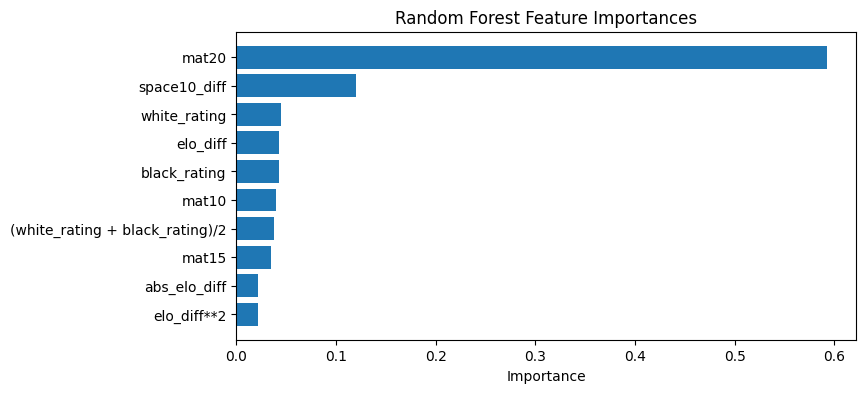

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# EXACT feature order used during RF training
feat_names = ['white_rating', 'black_rating', 'elo_diff',
              'elo_diff**2', 'abs_elo_diff', '(white_rating + black_rating)/2',
              'space10_diff', 'mat10', 'mat15', 'mat20']
importances = rf.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feat_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(imp_df)

# Plot
plt.figure(figsize=(8,4))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()


Model suggests: e2e4 CP: 48.978615


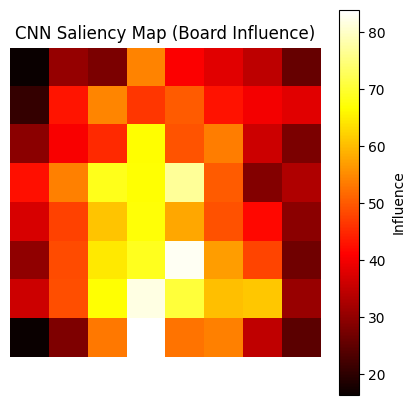


♟️  Engine Comparison

🤖 Model best move     : e2e4 (CNN predicts 48.98 cp)
💡 Stockfish best move : e2e4 (50 cp)
🔍 Stockfish eval of model move: 30 cp
✅ Model AGREES with Stockfish


In [38]:
def model_best_move(board):
    moves = list(board.legal_moves)
    # simpler version:
    tensors = []
    for mv in moves:
        board.push(mv)
        tensors.append(board_to_planes(board))
        board.pop()
    
    scores = model.predict(np.array(tensors), verbose=0).flatten()
    best_idx = np.argmax(scores) if board.turn == chess.WHITE else np.argmin(scores)
    return moves[best_idx].uci(), scores[best_idx]

best_move, score = model_best_move(board)
print("Model suggests:", best_move, "CP:", score)


import tensorflow as tf
import matplotlib.pyplot as plt

board_tensor = board_to_planes(board)

with tf.GradientTape() as tape:
    inp = tf.convert_to_tensor(board_tensor[None, ...])
    tape.watch(inp)
    pred = model(inp)

grads = tape.gradient(pred, inp)

# collapse 12 planes → single 8x8 heatmap
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()

plt.figure(figsize=(5,5))
plt.imshow(saliency, cmap='hot')
plt.colorbar(label="Influence")
plt.title("CNN Saliency Map (Board Influence)")
plt.axis('off')
plt.show()

from stockfish import Stockfish

# --- Initialize Stockfish ---
engine = Stockfish(
    path=r"C:\Users\vsriv\Downloads\stockfish-windows-x86-64-avx2\stockfish\stockfish-windows-x86-64-avx2.exe",
    depth=14   # you can say: deeper = stronger
)

# --- Stockfish best move from current position ---
engine.set_fen_position(board.fen())
sf_best = engine.get_best_move()
sf_eval = engine.get_evaluation()["value"]

# --- Evaluate model's suggested move with Stockfish ---
b_model = board.copy()
b_model.push_uci(best_move)
engine.set_fen_position(b_model.fen())
model_eval = engine.get_evaluation()["value"]

# --- Print comparison ---
print("\n♟️  Engine Comparison\n")
print(f"🤖 Model best move     : {best_move} (CNN predicts {score:.2f} cp)")
print(f"💡 Stockfish best move : {sf_best} ({sf_eval} cp)")
print(f"🔍 Stockfish eval of model move: {model_eval} cp")

diff = abs(model_eval - sf_eval)

if best_move == sf_best:
    print("✅ Model AGREES with Stockfish")
elif diff < 50:
    print(f"🟢 Model found a comparable move ({diff} cp difference)")
elif diff < 150:
    print(f"🟡 Model slightly worse ({diff} cp difference)")
else:
    print(f"🔴 Model significantly worse ({diff} cp difference)")



In [39]:
'''import chess
import chess.svg
from IPython.display import display, SVG

board = chess.Board()
display(SVG(chess.svg.board(board, size=400)))


def cnn_best_move(board):
    moves = list(board.legal_moves)
    tensors = []
    for mv in moves:
        board.push(mv)
        tensors.append(board_to_planes(board))
        board.pop()
    
    scores = model.predict(np.array(tensors), verbose=0).flatten()
    best_idx = np.argmax(scores) if board.turn == chess.WHITE else np.argmin(scores)
    return moves[best_idx], scores[best_idx]

while not board.is_game_over():
    display(SVG(chess.svg.board(board, size=400)))

    move = input("Your move (UCI e.g. e2e4): ")
    try:
        board.push_uci(move)
    except:
        print("❌ Illegal move")
        continue

    if board.is_game_over():
        break

    mv, cp = cnn_best_move(board)
    print(f"🤖 CNN plays {mv} | Eval: {round(cp,1)} cp")
    board.push(mv)

display(SVG(chess.svg.board(board, size=400)))
print("Game result:", board.result())
'''

'import chess\nimport chess.svg\nfrom IPython.display import display, SVG\n\nboard = chess.Board()\ndisplay(SVG(chess.svg.board(board, size=400)))\n\n\ndef cnn_best_move(board):\n    moves = list(board.legal_moves)\n    tensors = []\n    for mv in moves:\n        board.push(mv)\n        tensors.append(board_to_planes(board))\n        board.pop()\n\n    scores = model.predict(np.array(tensors), verbose=0).flatten()\n    best_idx = np.argmax(scores) if board.turn == chess.WHITE else np.argmin(scores)\n    return moves[best_idx], scores[best_idx]\n\nwhile not board.is_game_over():\n    display(SVG(chess.svg.board(board, size=400)))\n\n    move = input("Your move (UCI e.g. e2e4): ")\n    try:\n        board.push_uci(move)\n    except:\n        print("❌ Illegal move")\n        continue\n\n    if board.is_game_over():\n        break\n\n    mv, cp = cnn_best_move(board)\n    print(f"🤖 CNN plays {mv} | Eval: {round(cp,1)} cp")\n    board.push(mv)\n\ndisplay(SVG(chess.svg.board(board, size=400)

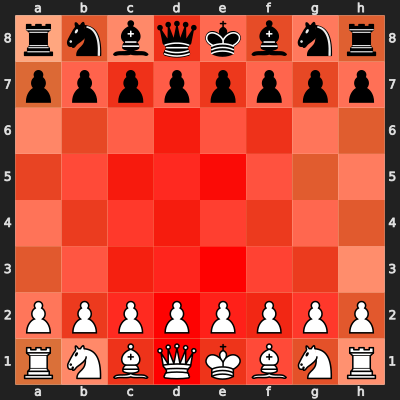

In [40]:
import chess.svg
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

# normalize saliency
heat = saliency / saliency.max()

# create square colors
colors = {}
for r in range(8):
    for c in range(8):
        sq = chess.square(c, 7-r)
        val = heat[r, c]
        colors[sq] = f"rgba(255,0,0,{val})"

display(SVG(chess.svg.board(
    board=board,
    fill=colors,
    size=400
)))


100%|██████████| 50/50 [00:06<00:00,  7.84it/s]


📈 Correlation: 0.506


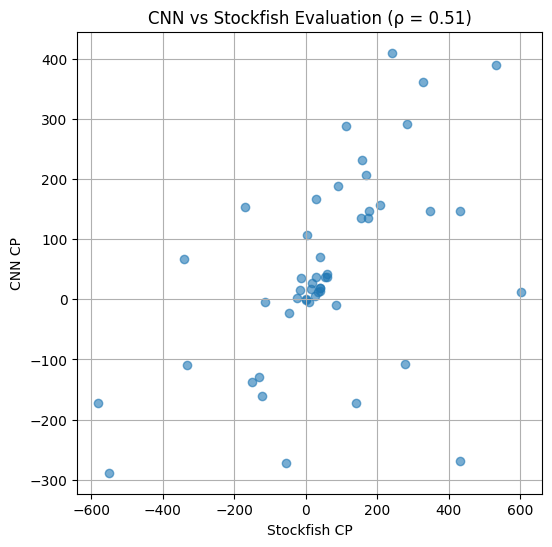

In [41]:
import random
import pandas as pd
from tqdm import tqdm

cnn_vals, sf_vals = [], []

for _ in tqdm(range(50)):
    sample = df.sample(1).iloc[0]
    board = board_after_fullmove(sample["moves"], 10)

    # CNN eval
    cnn_cp = model.predict(board_to_planes(board)[None, ...], verbose=0)[0][0]

    # Stockfish eval
    engine.set_fen_position(board.fen())
    sf_cp = engine.get_evaluation()["value"]
    sf_cp = int(np.clip(sf_cp, -1500, 1500))

    cnn_vals.append(cnn_cp)
    sf_vals.append(sf_cp)

corr = np.corrcoef(cnn_vals, sf_vals)[0,1]
print("📈 Correlation:", round(corr, 3))

plt.figure(figsize=(6,6))
plt.scatter(sf_vals, cnn_vals, alpha=0.6)
plt.xlabel("Stockfish CP")
plt.ylabel("CNN CP")
plt.title(f"CNN vs Stockfish Evaluation (ρ = {corr:.2f})")
plt.grid(True)
plt.show()


In [42]:
import pickle
import os

# create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# --- Save CNN ---
model.save("models/cnn_model.keras")
print("✅ CNN saved")

# --- Save sklearn models ---
with open("models/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("✅ Random Forest saved")

with open("models/mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)
print("✅ MLP saved")

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved")

with open("models/weight_model.pkl", "wb") as f:
    pickle.dump(weight_model, f)
print("✅ Ridge weight model saved")

print("\n✅ All models saved to /models folder")

✅ CNN saved
✅ Random Forest saved
✅ MLP saved
✅ Scaler saved
✅ Ridge weight model saved

✅ All models saved to /models folder
